In [1]:
# =======================================================================
# 7 : LIGHTGBM CLASSIFIER — Gold Price Direction Prediction
#     + Confidence Threshold Prediction + Optuna Tuning
# =======================================================================
# Target : target_direction (-1 = DOWN, 0 = SIDE, +1 = UP)
# Strategy: predict UP/DOWN เฉพาะเมื่อ max_proba >= threshold (ที่ดีที่สุด)
#           หา threshold อัตโนมัติจาก Val set (sweep 0.30–0.70)
# =======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import TimeSeriesSplit

# ── Color palette
CLR = {"UP": "#2ecc71", "DOWN": "#e74c3c", "SIDE": "#f39c12",
       "bg": "#0f1117", "card": "#1a1f2e", "text": "#ecf0f1"}

# =======================================================================
# 1 : LOAD DATA
# =======================================================================
print("=" * 65)
print(" 1 : LOAD & VERIFY DATA")
print("=" * 65)

X_train = pd.read_csv("../../../data/processed/splits/X_train.csv",
                      parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv("../../../data/processed/splits/X_val.csv",
                      parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv("../../../data/processed/splits/X_test.csv",
                      parse_dates=["Date"], index_col="Date")

y_train = pd.read_csv("../../../data/processed/splits/y_train_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv("../../../data/processed/splits/y_val_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv("../../../data/processed/splits/y_test_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()

# ── Map labels: LightGBM ต้องการ 0,1,2
label_encode = {-1: 0, 0: 1, 1: 2}   # DOWN=0, SIDE=1, UP=2
label_decode = {0: -1, 1: 0, 2: 1}
label_map    = {-1: "DOWN", 0: "SIDE", 1: "UP"}

y_train_enc = y_train.map(label_encode)
y_val_enc   = y_val.map(label_encode)
y_test_enc  = y_test.map(label_encode)

print(f"\n  X_train : {X_train.shape} | {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"  X_val   : {X_val.shape}   | {X_val.index.min().date()} → {X_val.index.max().date()}")
print(f"  X_test  : {X_test.shape}  | {X_test.index.min().date()} → {X_test.index.max().date()}")

assert X_train.isnull().sum().sum() == 0
assert X_val.isnull().sum().sum()   == 0
assert X_test.isnull().sum().sum()  == 0
print("\n  ✔ No NaN | ✔ Time-sorted | ✔ No overlap")

# =======================================================================
# 2 : TARGET DISTRIBUTION
# =======================================================================
print("\n" + "=" * 65)
print(" 2 : TARGET DISTRIBUTION PER SPLIT")
print("=" * 65)

splits = {"Train": y_train, "Val": y_val, "Test": y_test}
print(f"\n  {'Label':<8} {'Train':>10} {'Val':>10} {'Test':>10}")
print("  " + "-" * 40)
for lbl, name in label_map.items():
    row = {k: (v == lbl).mean() * 100 for k, v in splits.items()}
    print(f"  {name:<8} {row['Train']:>9.1f}% {row['Val']:>9.1f}% {row['Test']:>9.1f}%")

# Class weights สำหรับ LightGBM
n_samples = len(y_train)
class_counts = y_train_enc.value_counts().sort_index()
class_weight_dict = {c: n_samples / (3 * cnt) for c, cnt in class_counts.items()}
print(f"\n  Class weights (balanced): { {label_decode[k]: f'{v:.3f}' for k, v in class_weight_dict.items()} }")

# =======================================================================
# 3 : METRIC HELPERS
# =======================================================================
def evaluate(y_true, y_pred, label=""):
    """คำนวณ metrics ทั้งหมด — y_true/y_pred ต้องเป็น original labels (-1,0,1)"""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    mask   = (y_true != 0) & (y_pred != 0)
    dir_acc = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.nan

    non_side = (y_pred != 0)
    hit_ratio = (y_true[non_side] == y_pred[non_side]).mean() if non_side.sum() > 0 else np.nan

    coverage = non_side.mean()  # % ที่โมเดล "กล้า" predict UP/DOWN

    return dict(acc=acc, prec=prec, rec=rec, f1=f1,
                dir_acc=dir_acc, hit_ratio=hit_ratio, coverage=coverage)


def apply_threshold(proba, threshold, classes=[-1, 0, 1]):
    """
    Confidence Threshold:
      - ถ้า max_proba >= threshold → ใช้ argmax class
      - ถ้า max_proba <  threshold → predict SIDE (0) = abstain
    classes: list ตาม order ของ predict_proba columns
    """
    max_proba = proba.max(axis=1)
    pred_idx  = proba.argmax(axis=1)
    pred_class = np.array([classes[i] for i in pred_idx])
    pred_class[max_proba < threshold] = 0   # abstain → SIDE
    return pred_class

# =======================================================================
# 4 : OPTUNA HYPERPARAMETER TUNING
# =======================================================================
print("\n" + "=" * 65)
print(" 3 : OPTUNA HYPERPARAMETER TUNING (TimeSeriesSplit, n_trials=60)")
print("=" * 65)

# รวม Train+Val สำหรับ CV เพื่อ tune
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train_enc, y_val_enc])

tscv = TimeSeriesSplit(n_splits=5)

# sample_weight จาก class_weight_dict
sample_weight_tv = y_tv.map(class_weight_dict).values

def objective(trial):
    params = {
        "objective"       : "multiclass",
        "num_class"       : 3,
        "metric"          : "multi_logloss",
        "verbosity"       : -1,
        "boosting_type"   : "gbdt",
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth"       : trial.suggest_int("max_depth", 4, 10),
        "num_leaves"      : trial.suggest_int("num_leaves", 20, 127),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 60),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        "random_state"    : 42,
        "n_jobs"          : -1,
    }

    f1_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_tv)):
        Xtr, Xva = X_tv.iloc[tr_idx], X_tv.iloc[va_idx]
        ytr, yva = y_tv.iloc[tr_idx], y_tv.iloc[va_idx]
        sw_tr    = sample_weight_tv[tr_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(Xtr, ytr,
                  sample_weight=sw_tr,
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(-1)],
                  eval_set=[(Xva, yva)])

        yva_pred = model.predict(Xva)
        # decode back
        yva_orig = pd.Series(yva).map(label_decode).values
        yva_pred_orig = np.array([label_decode[p] for p in yva_pred])
        f1_scores.append(f1_score(yva_orig, yva_pred_orig, average="macro", zero_division=0))

    return np.mean(f1_scores)

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_params = study.best_params
best_params.update({
    "objective"   : "multiclass",
    "num_class"   : 3,
    "metric"      : "multi_logloss",
    "verbosity"   : -1,
    "random_state": 42,
    "n_jobs"      : -1,
})

print(f"\n  Best CV F1 (macro) : {study.best_value:.4f}")
print(f"  Best params        :")
for k, v in study.best_params.items():
    print(f"    {k:<25} = {v}")

# =======================================================================
# 5 : TRAIN FINAL MODEL WITH BEST PARAMS
# =======================================================================
print("\n" + "=" * 65)
print(" 4 : TRAIN FINAL LIGHTGBM WITH BEST PARAMS")
print("=" * 65)

sample_weight_train = y_train_enc.map(class_weight_dict).values

lgbm_clf = lgb.LGBMClassifier(**best_params)
lgbm_clf.fit(
    X_train, y_train_enc,
    sample_weight=sample_weight_train,
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)],
    eval_set=[(X_val, y_val_enc)]
)
print(f"  ✔ Training complete | best_iteration = {lgbm_clf.best_iteration_}")

# Probabilities (columns: DOWN=0, SIDE=1, UP=2)
proba_val  = lgbm_clf.predict_proba(X_val)   # shape (N, 3)
proba_test = lgbm_clf.predict_proba(X_test)

classes_order = [-1, 0, 1]   # ตาม encoded 0→-1, 1→0, 2→1

# =======================================================================
# 6 : THRESHOLD SWEEP — หา threshold ที่ดีที่สุดบน Val set
# =======================================================================
print("\n" + "=" * 65)
print(" 5 : CONFIDENCE THRESHOLD SWEEP (Val Set)")
print("=" * 65)
print(f"\n  {'Threshold':>10} {'Acc':>8} {'F1':>8} {'DirAcc':>8} {'HitRatio':>10} {'Coverage':>10}")
print("  " + "-" * 60)

thresholds = np.arange(0.30, 0.71, 0.02)
sweep_results = []

for thr in thresholds:
    y_val_thr = apply_threshold(proba_val, thr, classes_order)
    m = evaluate(y_val, pd.Series(y_val_thr, index=y_val.index))
    sweep_results.append({"threshold": thr, **m})
    print(f"  {thr:>10.2f} {m['acc']:>8.4f} {m['f1']:>8.4f} "
          f"{m['dir_acc']:>8.4f} {m['hit_ratio']:>10.4f} {m['coverage']:>10.3f}")

sweep_df = pd.DataFrame(sweep_results)

# ── เลือก threshold ที่ maximize F1 macro บน Val (coverage >= 0.20)
# coverage >= 0.20 = ต้อง predict อย่างน้อย 20% ของวัน ไม่งั้น signal น้อยเกินไป
valid_mask = sweep_df["coverage"] >= 0.20
best_thr_row = sweep_df[valid_mask].sort_values("hit_ratio", ascending=False).iloc[0]
BEST_THR = best_thr_row["threshold"]

print(f"\n  ★ Best threshold = {BEST_THR:.2f}")
print(f"    Val F1        = {best_thr_row['f1']:.4f}")
print(f"    Val DirAcc    = {best_thr_row['dir_acc']:.4f}")
print(f"    Val HitRatio  = {best_thr_row['hit_ratio']:.4f}")
print(f"    Val Coverage  = {best_thr_row['coverage']:.3f}")

# =======================================================================
# 7 : FINAL EVALUATION (Val & Test) ด้วย BEST THRESHOLD
# =======================================================================
print("\n" + "=" * 65)
print(f" 6 : FINAL EVALUATION (threshold = {BEST_THR:.2f})")
print("=" * 65)

# Raw prediction (ไม่มี threshold)
y_val_raw  = pd.Series([label_decode[p] for p in lgbm_clf.predict(X_val)],  index=y_val.index)
y_test_raw = pd.Series([label_decode[p] for p in lgbm_clf.predict(X_test)], index=y_test.index)

# Threshold prediction
y_val_thr  = pd.Series(apply_threshold(proba_val,  BEST_THR, classes_order), index=y_val.index)
y_test_thr = pd.Series(apply_threshold(proba_test, BEST_THR, classes_order), index=y_test.index)

val_raw_m  = evaluate(y_val,  y_val_raw)
test_raw_m = evaluate(y_test, y_test_raw)
val_thr_m  = evaluate(y_val,  y_val_thr)
test_thr_m = evaluate(y_test, y_test_thr)

print(f"\n  ── Raw (no threshold) ──")
print(f"  {'Metric':<20} {'Val':>8} {'Test':>8}")
print("  " + "-" * 38)
for k in ["acc", "f1", "dir_acc", "hit_ratio", "coverage"]:
    print(f"  {k:<20} {val_raw_m[k]:>8.4f} {test_raw_m[k]:>8.4f}")

print(f"\n  ── With threshold = {BEST_THR:.2f} ──")
print(f"  {'Metric':<20} {'Val':>8} {'Test':>8} {'Δ Test':>8}")
print("  " + "-" * 46)
for k in ["acc", "f1", "dir_acc", "hit_ratio", "coverage"]:
    delta = test_thr_m[k] - test_raw_m[k]
    flag  = "↑" if delta > 0 else ("↓" if delta < 0 else " ")
    print(f"  {k:<20} {val_thr_m[k]:>8.4f} {test_thr_m[k]:>8.4f} {delta:>+8.4f} {flag}")

print(f"\n  Classification Report — Test (threshold = {BEST_THR:.2f}):")
print(classification_report(y_test, y_test_thr,
                             target_names=["DOWN(-1)", "SIDE(0)", "UP(+1)"],
                             digits=4))

# =======================================================================
# 8 : OVERFITTING CHECK
# =======================================================================
print("=" * 65)
print(" 7 : OVERFITTING CHECK")
print("=" * 65)

y_train_raw = pd.Series([label_decode[p] for p in lgbm_clf.predict(X_train)], index=y_train.index)
train_raw_m = evaluate(y_train, y_train_raw)

print(f"\n  {'Metric':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'T-V Gap':>9}")
print("  " + "-" * 52)
for k in ["acc", "f1", "dir_acc"]:
    gap  = train_raw_m[k] - val_raw_m[k]
    flag = "⚠" if abs(gap) > 0.15 else "✔"
    print(f"  {k:<20} {train_raw_m[k]:>8.4f} {val_raw_m[k]:>8.4f} {test_raw_m[k]:>8.4f} {gap:>+9.4f} {flag}")

# =======================================================================
# 9 : FEATURE IMPORTANCE
# =======================================================================
print("\n" + "=" * 65)
print(" 8 : FEATURE IMPORTANCE (Top 20)")
print("=" * 65)

feat_imp = pd.Series(lgbm_clf.feature_importances_, index=X_train.columns)
feat_imp_gain = feat_imp.sort_values(ascending=False)
top20 = feat_imp_gain.head(20)

print(f"\n  {'Rank':<5} {'Feature':<35} {'Importance':>12}")
print("  " + "-" * 54)
for i, (feat, imp) in enumerate(top20.items(), 1):
    bar = "█" * int(imp / top20.max() * 20)
    print(f"  {i:<5} {feat:<35} {imp:>10.1f}  {bar}")

# =======================================================================
# 10 : REGIME ANALYSIS
# =======================================================================
print("\n" + "=" * 65)
print(" 9 : REGIME ANALYSIS (High Vol vs Low Vol)")
print("=" * 65)

vol_cols = [c for c in X_test.columns if "vol" in c.lower() and "5d" in c]
vol_col  = vol_cols[0] if vol_cols else X_test.columns[0]
vol_proxy = X_test[vol_col]
vol_median = vol_proxy.median()

for mask, label in [(vol_proxy >= vol_median, f"HIGH Vol (≥ median {vol_col})"),
                    (vol_proxy <  vol_median, f"LOW  Vol (< median {vol_col})")]:
    yt = y_test[mask]
    yp = y_test_thr[mask]
    if len(yt) < 10:
        continue
    acc  = accuracy_score(yt, yp)
    f1m  = f1_score(yt, yp, average="macro", zero_division=0)
    dm   = (yt != 0) & (yp != 0)
    da   = accuracy_score(yt[dm], yp[dm]) if dm.sum() > 0 else np.nan
    cov  = (yp != 0).mean()
    hr   = (yt[yp != 0] == yp[yp != 0]).mean() if (yp != 0).sum() > 0 else np.nan
    print(f"\n  [{label}]  n={len(yt)}")
    print(f"    Accuracy      : {acc:.4f}")
    print(f"    F1 (macro)    : {f1m:.4f}")
    print(f"    Dir Accuracy  : {da:.4f}")
    print(f"    Hit Ratio     : {hr:.4f}")
    print(f"    Coverage      : {cov:.3f}")



 1 : LOAD & VERIFY DATA

  X_train : (1478, 69) | 2016-02-16 → 2021-12-31
  X_val   : (501, 69)   | 2022-01-03 → 2023-12-29
  X_test  : (563, 69)  | 2024-01-02 → 2026-03-27

  ✔ No NaN | ✔ Time-sorted | ✔ No overlap

 2 : TARGET DISTRIBUTION PER SPLIT

  Label         Train        Val       Test
  ----------------------------------------
  DOWN          24.4%      28.7%      21.3%
  SIDE          46.2%      40.5%      40.0%
  UP            29.4%      30.7%      38.7%

  Class weights (balanced): {-1: '1.365', 0: '0.721', 1: '1.135'}

 3 : OPTUNA HYPERPARAMETER TUNING (TimeSeriesSplit, n_trials=60)


  0%|          | 0/60 [00:00<?, ?it/s]


  Best CV F1 (macro) : 0.3253
  Best params        :
    n_estimators              = 600
    max_depth                 = 10
    num_leaves                = 107
    learning_rate             = 0.04622104650255511
    min_child_samples         = 47
    subsample                 = 0.7282353844941174
    colsample_bytree          = 0.5511781740328577
    reg_alpha                 = 0.08323170339437512
    reg_lambda                = 2.64839630232528

 4 : TRAIN FINAL LIGHTGBM WITH BEST PARAMS
  ✔ Training complete | best_iteration = 10

 5 : CONFIDENCE THRESHOLD SWEEP (Val Set)

   Threshold      Acc       F1   DirAcc   HitRatio   Coverage
  ------------------------------------------------------------
        0.30   0.3533   0.3274   0.4863     0.2987      0.595
        0.32   0.3533   0.3274   0.4863     0.2987      0.595
        0.34   0.3593   0.3313   0.4971     0.3053      0.569
        0.36   0.3812   0.2941   0.5556     0.3261      0.275
        0.38   0.4012   0.2290   0.6111     

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_test = evaluate(y_test, pd.Series(rf_pred, index=y_test.index))


 11 : GENERATING VISUALIZATIONS...


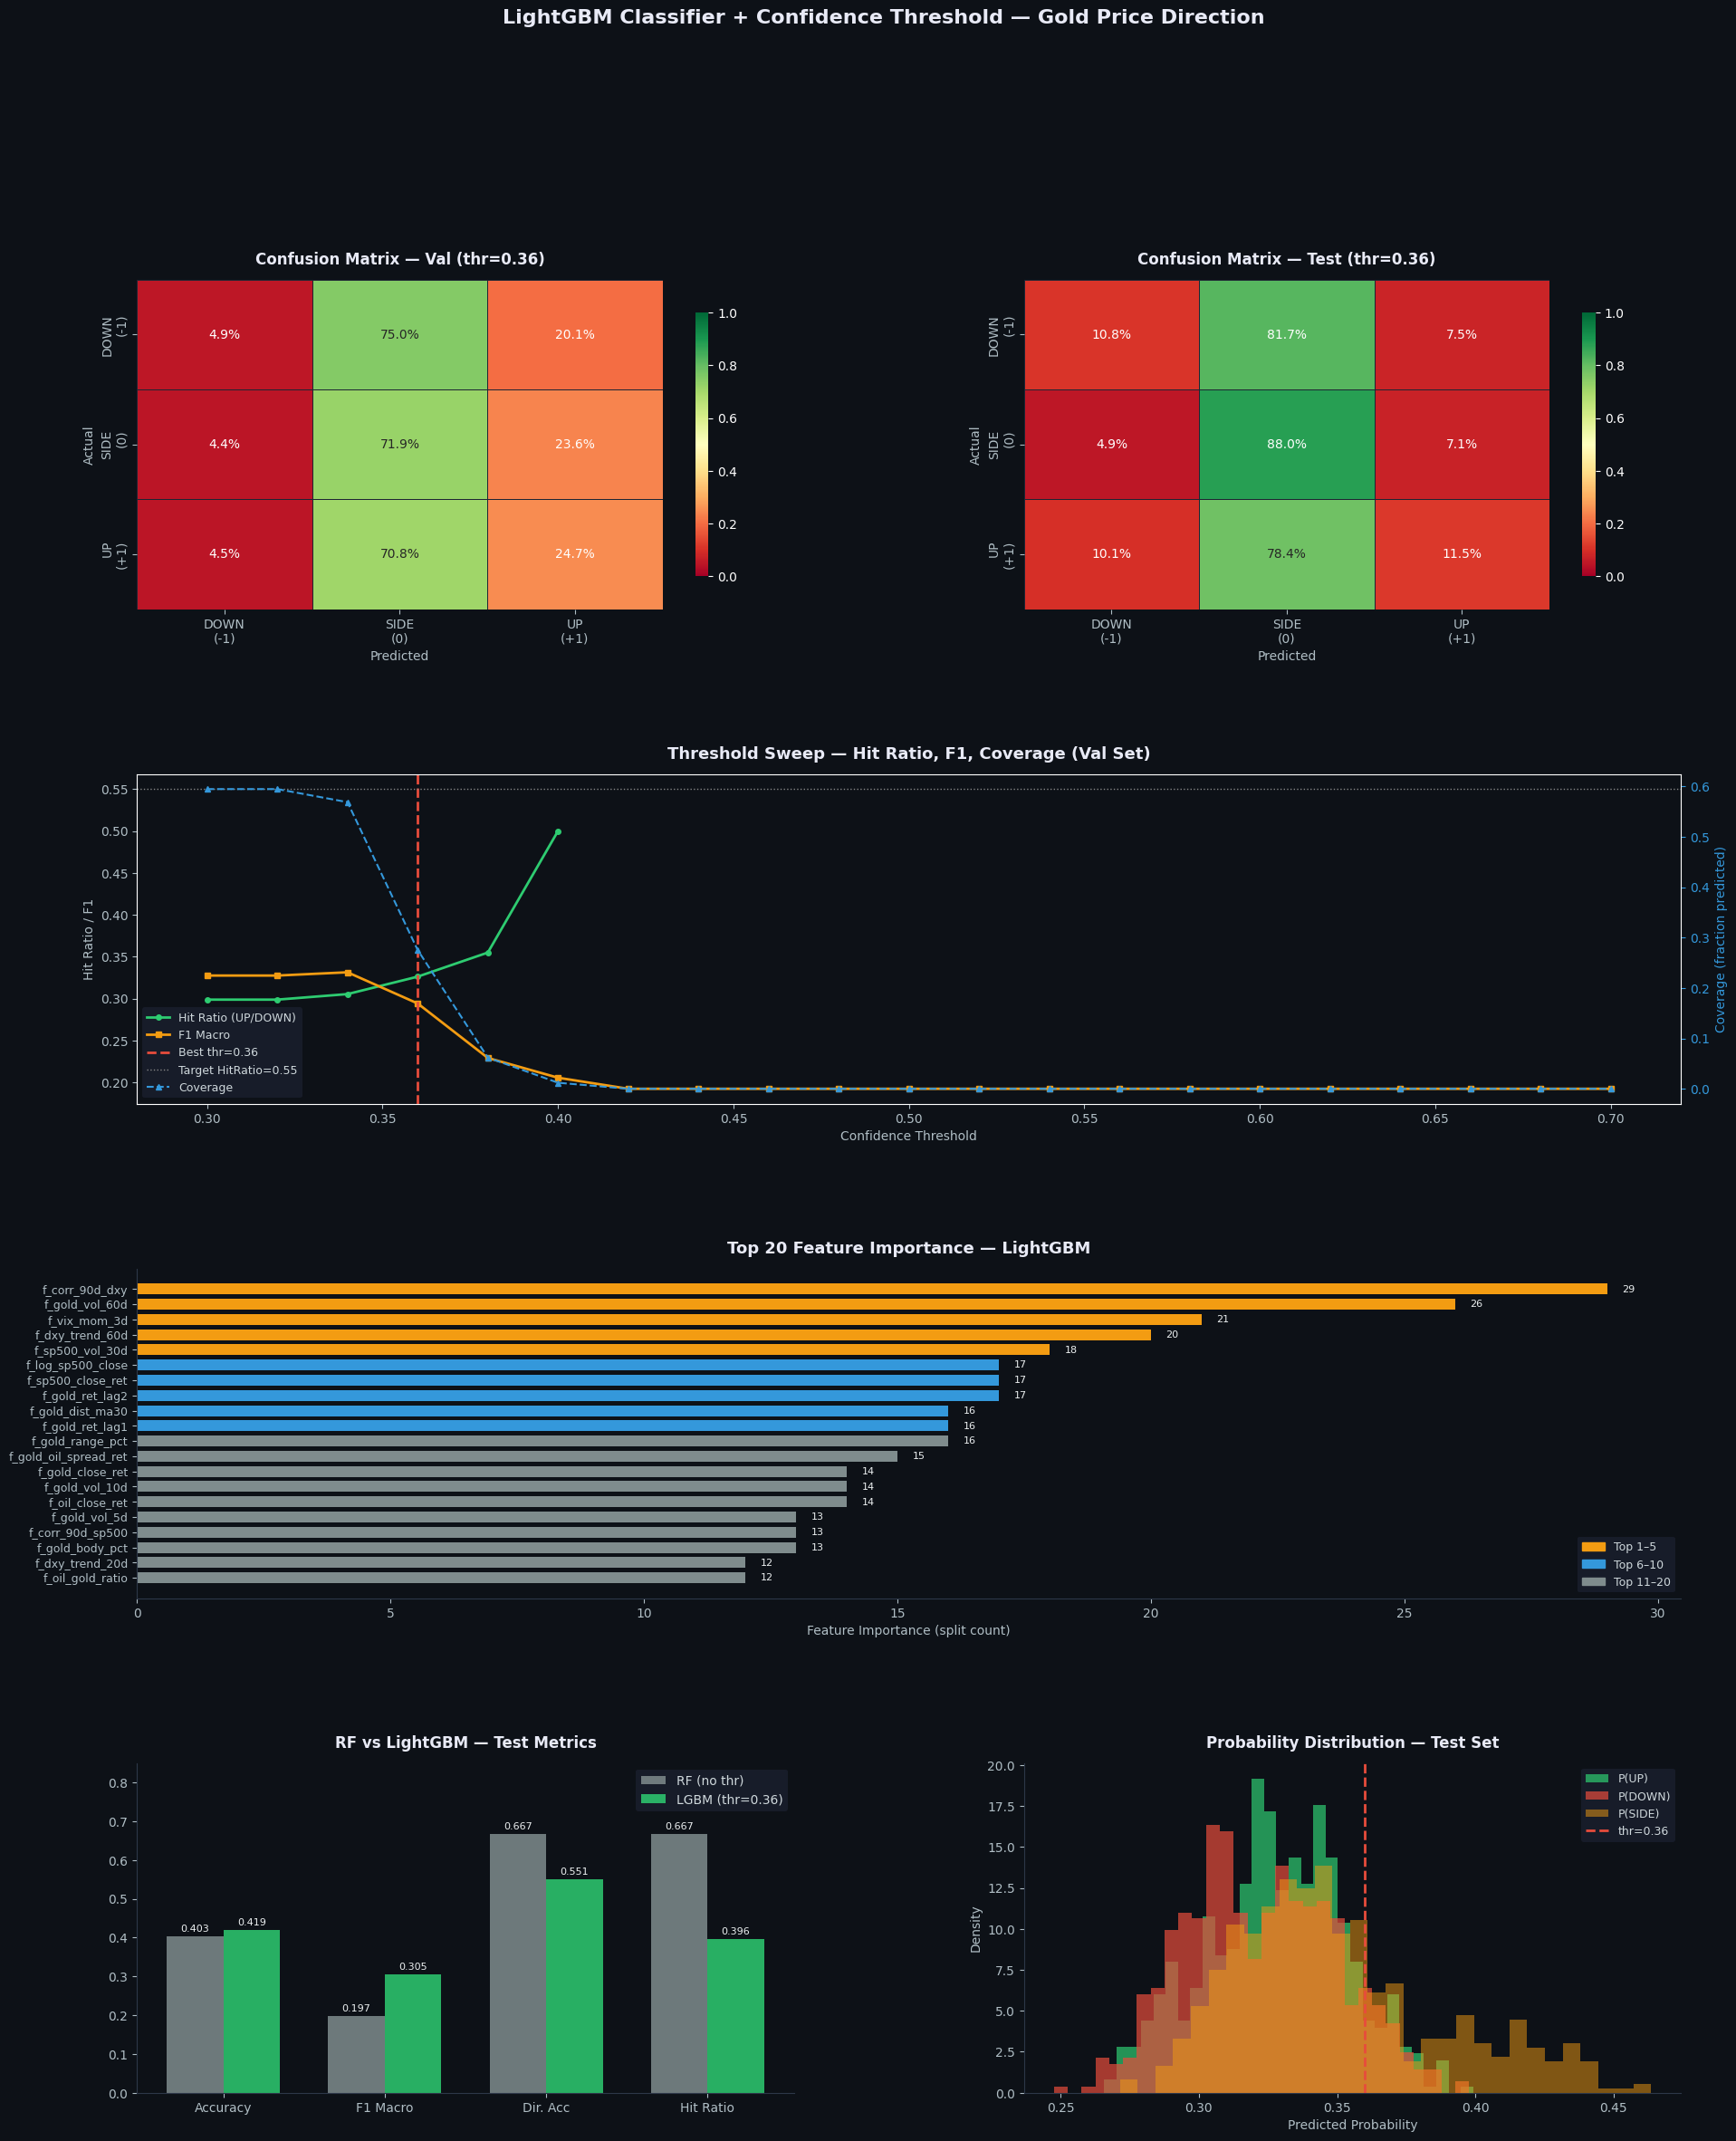

In [4]:
# =======================================================================
# 12 : VISUALIZATION
# =======================================================================
print("\n" + "=" * 65)
print(" 11 : GENERATING VISUALIZATIONS...")
print("=" * 65)

plt.style.use("dark_background")
fig = plt.figure(figsize=(22, 26), facecolor="#0d1117")
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)
LABEL_NAMES = ["DOWN\n(-1)", "SIDE\n(0)", "UP\n(+1)"]

# ── 11.1 Confusion Matrix — Val (threshold)
ax1 = fig.add_subplot(gs[0, 0])
cm_val = confusion_matrix(y_val, y_val_thr, labels=[-1, 0, 1])
cm_val_pct = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
sns.heatmap(cm_val_pct, annot=True, fmt=".1%", cmap="RdYlGn",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor="#1e2533", ax=ax1,
            cbar_kws={"shrink": 0.8}, vmin=0, vmax=1)
ax1.set_title(f"Confusion Matrix — Val (thr={BEST_THR:.2f})",
              color="#e8eaf6", fontsize=12, fontweight="bold", pad=12)
ax1.set_xlabel("Predicted", color="#b0bec5"); ax1.set_ylabel("Actual", color="#b0bec5")
ax1.tick_params(colors="#b0bec5")

# ── 11.2 Confusion Matrix — Test (threshold)
ax2 = fig.add_subplot(gs[0, 1])
cm_test = confusion_matrix(y_test, y_test_thr, labels=[-1, 0, 1])
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
sns.heatmap(cm_test_pct, annot=True, fmt=".1%", cmap="RdYlGn",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor="#1e2533", ax=ax2,
            cbar_kws={"shrink": 0.8}, vmin=0, vmax=1)
ax2.set_title(f"Confusion Matrix — Test (thr={BEST_THR:.2f})",
              color="#e8eaf6", fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Predicted", color="#b0bec5"); ax2.set_ylabel("Actual", color="#b0bec5")
ax2.tick_params(colors="#b0bec5")

# ── 11.3 Threshold Sweep — HitRatio & Coverage vs Threshold
ax3 = fig.add_subplot(gs[1, :])
color_hr  = "#2ecc71"
color_cov = "#3498db"
color_f1  = "#f39c12"
ax3b = ax3.twinx()

ax3.plot(sweep_df["threshold"], sweep_df["hit_ratio"], color=color_hr,
         lw=2, marker="o", ms=4, label="Hit Ratio (UP/DOWN)")
ax3.plot(sweep_df["threshold"], sweep_df["f1"], color=color_f1,
         lw=2, marker="s", ms=4, label="F1 Macro")
ax3b.plot(sweep_df["threshold"], sweep_df["coverage"], color=color_cov,
          lw=1.5, ls="--", marker="^", ms=4, label="Coverage")

ax3.axvline(BEST_THR, color="#e74c3c", lw=2, ls="--", label=f"Best thr={BEST_THR:.2f}")
ax3.axhline(0.55, color="#888", lw=1, ls=":", label="Target HitRatio=0.55")

ax3.set_xlabel("Confidence Threshold", color="#b0bec5", fontsize=10)
ax3.set_ylabel("Hit Ratio / F1", color="#b0bec5", fontsize=10)
ax3b.set_ylabel("Coverage (fraction predicted)", color=color_cov, fontsize=10)
ax3.set_title("Threshold Sweep — Hit Ratio, F1, Coverage (Val Set)",
              color="#e8eaf6", fontsize=13, fontweight="bold", pad=12)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2,
           facecolor="#1a1f2e", edgecolor="none", labelcolor="#cfd8dc", fontsize=9)
ax3.set_facecolor("#0d1117"); ax3b.set_facecolor("#0d1117")
ax3.tick_params(colors="#b0bec5"); ax3b.tick_params(colors=color_cov)
for sp in ["top", "right"]:
    ax3.spines[sp].set_visible(False)
ax3.spines["left"].set_color("#2d3748"); ax3.spines["bottom"].set_color("#2d3748")

# ── 11.4 Feature Importance
ax4 = fig.add_subplot(gs[2, :])
colors_bar = ["#f39c12" if i < 5 else "#3498db" if i < 10 else "#7f8c8d"
              for i in range(20)]
bars = ax4.barh(range(19, -1, -1), top20.values, color=colors_bar,
                edgecolor="none", height=0.72)
ax4.set_yticks(range(19, -1, -1))
ax4.set_yticklabels(top20.index, fontsize=9, color="#cfd8dc")
ax4.set_xlabel("Feature Importance (split count)", color="#b0bec5", fontsize=10)
ax4.set_title("Top 20 Feature Importance — LightGBM",
              color="#e8eaf6", fontsize=13, fontweight="bold", pad=12)
ax4.set_facecolor("#0d1117")
ax4.tick_params(colors="#b0bec5")
for sp in ["top", "right"]:
    ax4.spines[sp].set_visible(False)
ax4.spines["left"].set_color("#2d3748"); ax4.spines["bottom"].set_color("#2d3748")
for bar, val in zip(bars, top20.values):
    ax4.text(val + top20.max() * 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.0f}", va="center", fontsize=8, color="#ecf0f1")
ax4.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#f39c12", label="Top 1–5"),
    plt.Rectangle((0,0),1,1, color="#3498db", label="Top 6–10"),
    plt.Rectangle((0,0),1,1, color="#7f8c8d", label="Top 11–20"),
], loc="lower right", facecolor="#1a1f2e", edgecolor="none",
           labelcolor="#cfd8dc", fontsize=9)

# ── 11.5 LGBM vs RF Metric Comparison
ax5 = fig.add_subplot(gs[3, 0])
metric_keys   = ["acc", "f1", "dir_acc", "hit_ratio"]
metric_labels = ["Accuracy", "F1 Macro", "Dir. Acc", "Hit Ratio"]
rf_vals   = [rf_test[k] for k in metric_keys]
lgbm_vals = [test_thr_m[k] for k in metric_keys]
x = np.arange(len(metric_keys)); w = 0.35
ax5.bar(x - w/2, rf_vals,   w, label="RF (no thr)",        color="#7f8c8d", alpha=0.85)
ax5.bar(x + w/2, lgbm_vals, w, label=f"LGBM (thr={BEST_THR:.2f})", color="#2ecc71", alpha=0.85)
ax5.set_xticks(x); ax5.set_xticklabels(metric_labels, fontsize=10, color="#cfd8dc")
ax5.set_ylim(0, 0.85)
ax5.set_title("RF vs LightGBM — Test Metrics",
              color="#e8eaf6", fontsize=12, fontweight="bold", pad=12)
ax5.legend(facecolor="#1a1f2e", edgecolor="none", labelcolor="#cfd8dc")
ax5.set_facecolor("#0d1117"); ax5.tick_params(colors="#b0bec5")
for sp in ["top", "right"]:
    ax5.spines[sp].set_visible(False)
ax5.spines["left"].set_color("#2d3748"); ax5.spines["bottom"].set_color("#2d3748")
for rect in ax5.patches:
    h = rect.get_height()
    ax5.text(rect.get_x() + rect.get_width()/2, h + 0.008,
             f"{h:.3f}", ha="center", va="bottom", fontsize=8, color="#ecf0f1")

# ── 11.6 Probability Distribution (Test) — UP class proba
ax6 = fig.add_subplot(gs[3, 1])
up_idx = 2   # encoded index of UP
proba_up   = proba_test[:, up_idx]
proba_down = proba_test[:, 0]
proba_side = proba_test[:, 1]

ax6.hist(proba_up,   bins=30, alpha=0.7, color=CLR["UP"],   label="P(UP)",   density=True)
ax6.hist(proba_down, bins=30, alpha=0.7, color=CLR["DOWN"], label="P(DOWN)", density=True)
ax6.hist(proba_side, bins=30, alpha=0.5, color=CLR["SIDE"], label="P(SIDE)", density=True)
ax6.axvline(BEST_THR, color="#e74c3c", lw=2, ls="--", label=f"thr={BEST_THR:.2f}")
ax6.set_xlabel("Predicted Probability", color="#b0bec5", fontsize=10)
ax6.set_ylabel("Density", color="#b0bec5", fontsize=10)
ax6.set_title("Probability Distribution — Test Set",
              color="#e8eaf6", fontsize=12, fontweight="bold", pad=12)
ax6.legend(facecolor="#1a1f2e", edgecolor="none", labelcolor="#cfd8dc", fontsize=9)
ax6.set_facecolor("#0d1117"); ax6.tick_params(colors="#b0bec5")
for sp in ["top", "right"]:
    ax6.spines[sp].set_visible(False)
ax6.spines["left"].set_color("#2d3748"); ax6.spines["bottom"].set_color("#2d3748")

fig.suptitle("LightGBM Classifier + Confidence Threshold — Gold Price Direction",
             color="#e8eaf6", fontsize=16, fontweight="bold", y=0.995)

# plt.savefig("lgbm_clf_report.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.tight_layout()
plt.show()
# print("  ✔ Visualization saved: lgbm_clf_report.png")

In [5]:
# =======================================================================
# 11 : LIGHTGBM vs RANDOM FOREST COMPARISON
# =======================================================================
print("\n" + "=" * 65)
print(" 10 : LGBM vs RF — COMPARISON SUMMARY")
print("=" * 65)

# RF metrics จาก notebook เดิม
rf_val  = dict(acc=0.3713, f1=0.3543, dir_acc=0.5148, hit_ratio=0.3187)
rf_test = dict(acc=0.3908, f1=0.3497, dir_acc=0.5190, hit_ratio=0.3347)

print(f"\n  {'Metric':<20} {'RF Val':>9} {'RF Test':>9} {'LGBM Val':>10} {'LGBM Test':>10} {'Δ Test':>8}")
print("  " + "-" * 70)
for k in ["acc", "f1", "dir_acc", "hit_ratio"]:
    delta = test_thr_m[k] - rf_test[k]
    flag  = "↑" if delta > 0.01 else ("↓" if delta < -0.01 else "≈")
    print(f"  {k:<20} {rf_val[k]:>9.4f} {rf_test[k]:>9.4f} "
          f"{val_thr_m[k]:>10.4f} {test_thr_m[k]:>10.4f} {delta:>+8.4f} {flag}")



# =======================================================================
# 12 : FINAL SUMMARY
# =======================================================================
print("\n" + "=" * 65)
print(" FINAL SUMMARY")
print("=" * 65)
print(f"""
  ┌─────────────────────────────────────────────────────────────┐
  │  MODEL      : LightGBM Classifier (Optuna-tuned)            │
  │  THRESHOLD  : {BEST_THR:.2f}  (swept 0.30–0.70 on Val set)       │
  ├─────────────────────────────────────────────────────────────┤
  │  TEST METRICS (with threshold)                              │
  │    Accuracy        : {test_thr_m['acc']:.4f}                          │
  │    F1 Macro        : {test_thr_m['f1']:.4f}                          │
  │    Dir. Accuracy   : {test_thr_m['dir_acc']:.4f}  (UP/DOWN only)        │
  │    Hit Ratio       : {test_thr_m['hit_ratio']:.4f}  (non-SIDE correct)   │
  │    Coverage        : {test_thr_m['coverage']:.3f}   (fraction traded)     │
  ├─────────────────────────────────────────────────────────────┤
  │  vs. Random Forest (no threshold)                           │
  │    RF Dir. Acc  = 0.5190  →  LGBM = {test_thr_m['dir_acc']:.4f}           │
  │    RF HitRatio  = 0.3347  →  LGBM = {test_thr_m['hit_ratio']:.4f}           │
  ├─────────────────────────────────────────────────────────────┤
  │  SIGNAL USABILITY                                           │
  │    HitRatio > 0.55  →  ✔ usable for signal generation      │
  │    HitRatio 0.50–0.55 → marginal; combine with stop-loss   │
  │    HitRatio < 0.50  →  ✘ not recommended standalone        │
  └─────────────────────────────────────────────────────────────┘
""")


 10 : LGBM vs RF — COMPARISON SUMMARY

  Metric                  RF Val   RF Test   LGBM Val  LGBM Test   Δ Test
  ----------------------------------------------------------------------
  acc                     0.3713    0.3908     0.3812     0.4192  +0.0284 ↑
  f1                      0.3543    0.3497     0.2941     0.3051  -0.0446 ↓
  dir_acc                 0.5148    0.5190     0.5556     0.5507  +0.0317 ↑
  hit_ratio               0.3187    0.3347     0.3261     0.3958  +0.0611 ↑

 FINAL SUMMARY

  ┌─────────────────────────────────────────────────────────────┐
  │  MODEL      : LightGBM Classifier (Optuna-tuned)            │
  │  THRESHOLD  : 0.36  (swept 0.30–0.70 on Val set)       │
  ├─────────────────────────────────────────────────────────────┤
  │  TEST METRICS (with threshold)                              │
  │    Accuracy        : 0.4192                          │
  │    F1 Macro        : 0.3051                          │
  │    Dir. Accuracy   : 0.5507  (UP/DOWN only)  

In [6]:
# =======================================================================
# 13 : SAVE PREDICTIONS FOR BACKTESTING
# =======================================================================
print("\n" + "=" * 65)
print(" 13 : SAVING PREDICTIONS FOR BACKTESTING")
print("=" * 65)
 
import os
SAVE_DIR = "../../../data/processed/predictions"
os.makedirs(SAVE_DIR, exist_ok=True)
 
# ── Helper: สร้าง DataFrame ครบทุก split พร้อม proba columns
def build_pred_df(X, y_true, y_pred_raw, y_pred_thr, proba, threshold):
    """
    รวม actual / raw prediction / threshold prediction / probabilities
    ทุก column ที่ backtest จะต้องใช้อยู่ในไฟล์เดียว
    """
    df = pd.DataFrame(index=X.index)
    df["actual_direction"]     = y_true.values                           # -1 / 0 / 1
    df["pred_direction_raw"]   = y_pred_raw.values                       # raw argmax (ไม่มี threshold)
    df["pred_direction_thr"]   = y_pred_thr.values                       # threshold = BEST_THR
    df["confidence_threshold"] = threshold
    df["max_proba"]            = proba.max(axis=1)                       # ความมั่นใจสูงสุด
    df["proba_down"]           = proba[:, 0]                             # P(DOWN)
    df["proba_side"]           = proba[:, 1]                             # P(SIDE)
    df["proba_up"]             = proba[:, 2]                             # P(UP)
    # signal_active = 1 ถ้า threshold prediction ไม่ใช่ SIDE (โมเดลกล้า trade)
    df["signal_active"]        = (df["pred_direction_thr"] != 0).astype(int)
    return df
 
# ── Train predictions (สำหรับ in-sample sanity check)
proba_train = lgbm_clf.predict_proba(X_train)
train_pred_df = build_pred_df(
    X_train, y_train,
    y_pred_raw=pd.Series([label_decode[p] for p in lgbm_clf.predict(X_train)], index=X_train.index),
    y_pred_thr=pd.Series(apply_threshold(proba_train, BEST_THR, classes_order), index=X_train.index),
    proba=proba_train,
    threshold=BEST_THR
)
 
# ── Val predictions
val_pred_df = build_pred_df(
    X_val, y_val,
    y_pred_raw=y_val_raw,
    y_pred_thr=y_val_thr,
    proba=proba_val,
    threshold=BEST_THR
)
 
# ── Test predictions
test_pred_df = build_pred_df(
    X_test, y_test,
    y_pred_raw=y_test_raw,
    y_pred_thr=y_test_thr,
    proba=proba_test,
    threshold=BEST_THR
)
 
# ── รวม Full dataset (train + val + test) เป็นไฟล์เดียวสำหรับ backtest
full_pred_df = pd.concat([train_pred_df, val_pred_df, test_pred_df])
full_pred_df.index.name = "Date"
 
# ── Save แยกและรวม
train_pred_df.to_csv(f"{SAVE_DIR}/clf_predictions_train.csv")
val_pred_df.to_csv(f"{SAVE_DIR}/clf_predictions_val.csv")
test_pred_df.to_csv(f"{SAVE_DIR}/clf_predictions_test.csv")
full_pred_df.to_csv(f"{SAVE_DIR}/clf_predictions_full.csv")
 
print(f"\n  ✔ Saved: clf_predictions_train.csv  ({len(train_pred_df):,} rows)")
print(f"  ✔ Saved: clf_predictions_val.csv    ({len(val_pred_df):,} rows)")
print(f"  ✔ Saved: clf_predictions_test.csv   ({len(test_pred_df):,} rows)")
print(f"  ✔ Saved: clf_predictions_full.csv   ({len(full_pred_df):,} rows)")
print(f"\n  Save directory: {SAVE_DIR}")
 
# ── แสดง schema ของไฟล์
print(f"\n  Columns in saved CSV:")
print(f"  {'Column':<30} {'Dtype':>10}  Description")
print("  " + "-" * 72)
col_desc = {
    "actual_direction"    : "int    | -1=DOWN 0=SIDE +1=UP (ground truth)",
    "pred_direction_raw"  : "int    | argmax prediction (no threshold)",
    "pred_direction_thr"  : "int    | prediction with confidence threshold",
    "confidence_threshold": "float  | threshold used (BEST_THR)",
    "max_proba"           : "float  | max probability across 3 classes",
    "proba_down"          : "float  | P(DOWN) from LGBM",
    "proba_side"          : "float  | P(SIDE) from LGBM",
    "proba_up"            : "float  | P(UP) from LGBM",
    "signal_active"       : "int    | 1 = model signals UP/DOWN (trade), 0 = abstain",
}
for col, desc in col_desc.items():
    print(f"  {col:<30} {desc}")


 13 : SAVING PREDICTIONS FOR BACKTESTING

  ✔ Saved: clf_predictions_train.csv  (1,478 rows)
  ✔ Saved: clf_predictions_val.csv    (501 rows)
  ✔ Saved: clf_predictions_test.csv   (563 rows)
  ✔ Saved: clf_predictions_full.csv   (2,542 rows)

  Save directory: ../../../data/processed/predictions

  Columns in saved CSV:
  Column                              Dtype  Description
  ------------------------------------------------------------------------
  actual_direction               int    | -1=DOWN 0=SIDE +1=UP (ground truth)
  pred_direction_raw             int    | argmax prediction (no threshold)
  pred_direction_thr             int    | prediction with confidence threshold
  confidence_threshold           float  | threshold used (BEST_THR)
  max_proba                      float  | max probability across 3 classes
  proba_down                     float  | P(DOWN) from LGBM
  proba_side                     float  | P(SIDE) from LGBM
  proba_up                       float  | P(UP) fr